# Tugas Besar PCD

1. Syahra Rizky Ramadhani Nasution (1301220066)
2. Fadil Rafliansyah (1301220154)
3. Puguh Aiman Ariyanto (1301223038)


## Tugas PCD

In [1]:
!pip install opencv-python scikit-learn matplotlib pillow

In [2]:
import cv2
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image
import os
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import LabelEncoder

## Menyiapkan Dataset

In [3]:
# from google.colab import files
# uploaded = files.upload()


In [4]:
!curl -L -o digikala-color-classification.zip\
    https://www.kaggle.com/api/v1/datasets/download/masouduut94/digikala-color-classification

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 35.8M  100 35.8M    0     0  26.3M      0  0:00:01  0:00:01 --:--:-- 26.3M


In [5]:
import zipfile
import os

# Path dataset
zip_file_path = '/content/digikala-color-classification.zip'
extract_path = '/content/train/'

# Ekstrak file ZIP
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

extracted_files = os.listdir(extract_path)
print(f"Isi direktori setelah ekstraksi: {extracted_files}")

Isi direktori setelah ekstraksi: ['train']


In [6]:
image_dir = '/content/train/train/'

# Menyiapkan paths gambar dan labels
image_paths = []
labels = []

for label in os.listdir(image_dir):
    label_dir = os.path.join(image_dir, label)

    if os.path.isdir(label_dir):
        for image_name in os.listdir(label_dir):
            image_path = os.path.join(label_dir, image_name)

            if image_path.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(image_path)
                labels.append(label)

print(f"Total images: {len(image_paths)}")

Total images: 6239


In [7]:
# Memeriksa isi setiap folder warna
for label in os.listdir(image_dir):
    label_dir = os.path.join(image_dir, label)
    if os.path.isdir(label_dir):
        images_in_folder = os.listdir(label_dir)
        print(f"Isi folder {label}: {images_in_folder}")


Isi folder purple: ['105459915.jpg', '117233002.jpg', '115495635.jpg', '117123789.jpg', '115512231.jpg', '115492163.jpg', '117133331.jpg', '117109232.jpg', '117263091.jpg', '117249040.jpg', '116981589.jpg', '117167721.jpg', '117064943.jpg', '105453662.jpg', '117222208.jpg', '117205231.jpg', '117140945.jpg', '105691210.jpg', '117100779.jpg', '105343459.jpg', '115505020.jpg', '105816963.jpg', '117220112.jpg', '117067224.jpg', '115729374.jpg', '117097655.jpg', '117281027.jpg', '117213535.jpg', '105549806.jpg', '115499524.jpg', '105832170.jpg', '105567446.jpg', '117219094.jpg', '117219125.jpg', '117226688.jpg', '117237639.jpg', '117149234.jpg', '105344581.jpg', '117198834.jpg', '121139645.jpg', '117287799.jpg', '117233167.jpg', '115493464.jpg', '105831858.jpg', '115490330.jpg', '105444923.jpg', '117277990.jpg', '117248242.jpg', '105681796.jpg', '117107748.jpg', '115503625.jpg', '117215336.jpg', '117277557.jpg', '116987172.jpg', '117203176.jpg', '115732986.jpg', '117203650.jpg', '117067169.

## Mengekstrak Fitur

In [8]:
# Memastikan tidak ada duplikasi
print("Daftar image_paths:")
print(image_paths)

unique_image_paths = list(set(image_paths))
print(f"\nJumlah gambar unik: {len(unique_image_paths)}")


Daftar image_paths:
['/content/train/train/purple/105459915.jpg', '/content/train/train/purple/117233002.jpg', '/content/train/train/purple/115495635.jpg', '/content/train/train/purple/117123789.jpg', '/content/train/train/purple/115512231.jpg', '/content/train/train/purple/115492163.jpg', '/content/train/train/purple/117133331.jpg', '/content/train/train/purple/117109232.jpg', '/content/train/train/purple/117263091.jpg', '/content/train/train/purple/117249040.jpg', '/content/train/train/purple/116981589.jpg', '/content/train/train/purple/117167721.jpg', '/content/train/train/purple/117064943.jpg', '/content/train/train/purple/105453662.jpg', '/content/train/train/purple/117222208.jpg', '/content/train/train/purple/117205231.jpg', '/content/train/train/purple/117140945.jpg', '/content/train/train/purple/105691210.jpg', '/content/train/train/purple/117100779.jpg', '/content/train/train/purple/105343459.jpg', '/content/train/train/purple/115505020.jpg', '/content/train/train/purple/10581

In [9]:
# def extract_dominant_color(image_path):
#     image = cv2.imread(image_path)
#     if image is None:
#         return None

#     # Konversi gambar ke HSV
#     hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

#     # Hitung histogram
#     hist = cv2.calcHist([hsv_image], [0, 1, 2], None, [180, 256, 256], [0, 180, 0, 256, 0, 256])

#     # Normalisasi histogram
#     hist /= hist.sum()

#     # Temukan warna dominan
#     max_val = np.argmax(hist)
#     hue = max_val // (256 * 256)
#     saturation = (max_val % (256 * 256)) // 256
#     value = max_val % 256

#     # Debugging
#     # print(f"Extracted features: Hue={hue}, Saturation={saturation}, Value={value}")

#     return hue, saturation, value


In [10]:
# # Ekstraksi fitur warna
# features = []
# for image_path in image_paths:
#     # print(f"Memproses gambar: {image_path}")  # Debugging
#     color_features = extract_dominant_color(image_path)
#     if color_features:
#         features.append(color_features)

# # Mengecek panjang fitur dan label
# print(f"Jumlah fitur yang diekstraksi: {len(features)}")


In [11]:
# Verifikasi format gambar
from PIL import Image

for image_path in image_paths:
    try:
        img = Image.open(image_path)
        img.verify()
        # print(f"Gambar valid: {image_path}") # Debugging
    except (IOError, SyntaxError) as e:
        print(f"[ERROR] Gambar tidak valid: {image_path}, Error: {e}")


In [12]:
import cv2
import numpy as np

def extract_color_histogram(image_path):
    # Memuat gambar
    image = cv2.imread(image_path)

    # Menghitung histogram untuk setiap saluran warna (RGB)
    hist_b = cv2.calcHist([image], [0], None, [256], [0, 256])  # Histogram untuk biru
    hist_g = cv2.calcHist([image], [1], None, [256], [0, 256])  # Histogram untuk hijau
    hist_r = cv2.calcHist([image], [2], None, [256], [0, 256])  # Histogram untuk merah

    # Gabungkan histogram untuk RGB menjadi satu fitur
    hist_features = np.concatenate((hist_b, hist_g, hist_r), axis=0)

    return hist_features.flatten()


In [13]:
def extract_hsv_histogram(image_path):
    # Memuat gambar
    image = cv2.imread(image_path)

    # Konversi gambar ke ruang warna HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Menghitung histogram untuk saluran H, S, V
    hist_h = cv2.calcHist([hsv_image], [0], None, [180], [0, 180])  # Histogram untuk Hue
    hist_s = cv2.calcHist([hsv_image], [1], None, [256], [0, 256])  # Histogram untuk Saturation
    hist_v = cv2.calcHist([hsv_image], [2], None, [256], [0, 256])  # Histogram untuk Value

    # Gabungkan histogram untuk H, S, V menjadi satu fitur
    hist_features = np.concatenate((hist_h, hist_s, hist_v), axis=0)

    return hist_features.flatten()


In [14]:
# Segmentasi dengan K-Means Clustering
def segmentation_kmeans_hsv(image):
    h, w, _ = image.shape
    pixels = image.reshape((-1, 3))
    pixels = np.float32(pixels)

    # K-Means parameters
    k_clusters = 3
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

    ret, labels_kmeans, centers = cv2.kmeans(pixels, k_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    best_cluster_label = -1
    max_score = -1

    # Cari cluster terbaik (heuristik: saturasi rata-rata dan jumlah piksel)
    for i in range(k_clusters):
        cluster_mask = (labels_kmeans == i).reshape(h, w).astype(np.uint8) * 255
        hsv_pixels_in_cluster = image[cluster_mask > 0]

        # Hitung saturasi rata-rata kluster
        if len(hsv_pixels_in_cluster) > 0:
            avg_saturation = np.mean(hsv_pixels_in_cluster[:, 1])
            # Saturation > 5
            colored_pixels_count = np.sum(hsv_pixels_in_cluster[:, 1] > 5)

            current_score = avg_saturation * colored_pixels_count
            if current_score > max_score:
                max_score = current_score
                best_cluster_label = i

    # Tidak ada cluster yang bisa digunakan
    if best_cluster_label == -1:
        return None

    # Buat mask dari cluster terbaik
    product_mask = (labels_kmeans == best_cluster_label).reshape(h, w).astype(np.uint8) * 255

    masked_image = cv2.bitwise_and(image, image, mask=product_mask)

    # Hanya gunakan segmentasi jika hasilnya tidak kosong
    if masked_image.shape[0] == 0:
        return None

    # # Debugging
    # print(best_cluster_label)
    # plt.imshow(product_mask)
    # plt.show()

    return product_mask

In [15]:
# Fungsi untuk mengekstrak 3 fitur (HSV)
def extract_dominant_color_hsv(image_path):
    # Memuat gambar
    image = cv2.imread(image_path)
    if image is None:
        return None

    # Konversi gambar ke HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Segmentasi
    segmentation_mask = segmentation_kmeans_hsv(hsv_image)

    # Hitung histogram
    # Gunakan bin 18, 16, 16
    hist = cv2.calcHist([hsv_image], [0, 1, 2], segmentation_mask, [18, 16, 16], [0, 180, 0, 256, 0, 256])

    # Normalisasi histogram
    hist /= hist.sum()

    # Temukan warna dominan
    max_idx = np.unravel_index(np.argmax(hist), hist.shape)
    hue = max_idx[0] * (180 // hist.shape[0])  # 180 / 18 = 10
    saturation = max_idx[1] * (256 // hist.shape[1]) # 256 / 16 = 16
    value = max_idx[2] * (256 // hist.shape[2])  # 256 / 16 = 16

    return hue, saturation, value


In [16]:
# Debugging
print(extract_dominant_color_hsv(image_paths[0]))
print(extract_dominant_color_hsv(image_paths[1]))
print(extract_dominant_color_hsv(image_paths[5]))
print(extract_dominant_color_hsv('/content/train/train/green/105844561.jpg'))

(np.int64(170), np.int64(144), np.int64(80))
(np.int64(140), np.int64(80), np.int64(176))
(np.int64(150), np.int64(64), np.int64(128))
(np.int64(0), np.int64(0), np.int64(48))


In [17]:
# Ekstraksi fitur warna untuk setiap gambar dan periksa hasilnya
features = []
for image_path in image_paths:
    color_features = extract_dominant_color_hsv(image_path)
    if color_features:
        features.append(color_features)
    else:
        print(f"[WARNING] Gagal memproses gambar: {image_path}")

# Cek panjang fitur dan label
print(f"Jumlah fitur yang diekstraksi: {len(features)}")
print(f"Jumlah label: {len(labels)}")

# Pastikan panjang fitur dan label konsisten
if len(features) == len(labels):
    X = np.array(features)
    y = np.array(labels)
else:
    print(f"[ERROR] Jumlah fitur ({len(features)}) tidak cocok dengan jumlah label ({len(labels)})")


Jumlah fitur yang diekstraksi: 6239
Jumlah label: 6239


## Data Latih dan Pengujian

In [18]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Jumlah sampel pelatihan: {len(X_train)}")
print(f"Jumlah sampel pengujian: {len(X_test)}")

Jumlah sampel pelatihan: 4367
Jumlah sampel pengujian: 1872


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Proses target dengan LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate((y_train, y_test)))

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [20]:
# Melatih model KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train_encoded)


KNeighborsClassifier(n_neighbors=7)

In [21]:
# Evaluasi model KNN pada data pelatihan
y_pred_train = knn.predict(X_train)
accuracy_train = accuracy_score(y_train_encoded, y_pred_train)
print(f"Akurasi pada data pelatihan: {accuracy_train * 100:.2f}%")

# Evaluasi akurasi pada data uji
y_pred = knn.predict(X_test)
accuracy_test = accuracy_score(y_test_encoded, y_pred)
print(f"Akurasi pada data uji: {accuracy_test * 100:.2f}%")


Akurasi pada data pelatihan: 68.88%
Akurasi pada data uji: 63.03%


## Menampilkan Gambar dan Prediksi

/content/train/train/green/1000010559.jpg


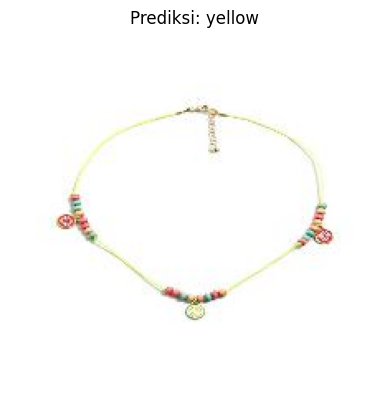

In [27]:
# Fungsi untuk menampilkan gambar dan prediksi warna
def display_image_and_prediction(model, label_names, image_paths):
    random_image_path = random.choice(image_paths)
    img = Image.open(random_image_path)

    # Ekstraksi fitur warna dominan
    color_features = extract_dominant_color_hsv(random_image_path)

    if color_features:
        img_array = np.array(color_features).reshape(1, -1)  # Menyesuaikan dimensi untuk prediksi

        # Prediksi menggunakan model
        prediction = model.predict(img_array)
        predicted_label = label_names[prediction[0]]  # Mengambil label prediksi

        # Menampilkan gambar dan prediksi
        print(random_image_path)
        plt.imshow(img)
        plt.title(f'Prediksi: {predicted_label}')
        plt.axis('off')
        plt.show()

display_image_and_prediction(knn, label_encoder.classes_, image_paths)

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

       black       0.53      0.58      0.55       100
        blue       0.74      0.88      0.81       195
       brown       0.62      0.73      0.67       204
       green       0.76      0.63      0.69       211
        grey       0.43      0.54      0.48       206
      orange       0.53      0.50      0.51        96
        pink       0.52      0.66      0.58       102
      purple       0.78      0.55      0.64       106
         red       0.77      0.77      0.77       207
      silver       0.34      0.14      0.20       105
       white       0.63      0.53      0.58       212
      yellow       0.74      0.77      0.75       128

    accuracy                           0.63      1872
   macro avg       0.62      0.61      0.60      1872
weighted avg       0.63      0.63      0.62      1872



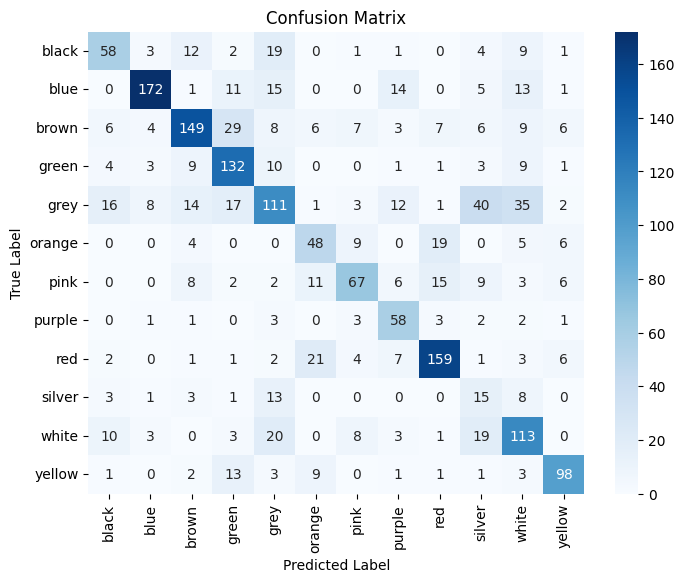

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_pred, y_test_encoded)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Export model untuk dipakai di aplikasi

In [30]:
import joblib

# Save model KNN dan label encoder
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("Model berhasil disimpan")


Model berhasil disimpan
